In [2]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [3]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData, Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(Integer, primary_key=True)
    city_name = Column(String(50))
    main_weather = Column(String(50))
    description = Column(String(100))
    temperature = Column(Float)
    feels_like=Column(Float)
    temp_min=Column(Float)
    temp_max=Column(Float)

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-22 18:08:01,493 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-22 18:08:01,494 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-22 18:08:01,497 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-22 18:08:01,499 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-22 18:08:01,500 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-22 18:08:01,501 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-22 18:08:01,504 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-22 18:08:01,504 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`weather`
2026-06-22 18:08:01,506 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-22 18:08:01,511 INFO sqlalchemy.engine.Engine COMMIT


In [4]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import json,requests
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,AIMessage
from pydantic import BaseModel,Field

class WeatherLoc(BaseModel):
    location:str=Field(description="the location to get the weather")
    
class WeatherInfo(BaseModel):
    """Extracted weather information for a city"""
    city_id:str=Field(...,description="The unique identifier for the city")
    city_name:Optional[str]=Field(description="name of the city")
    main_weather:str=Field(description="main weather condition")
    description:Optional[str]=Field(description="a detailed description of the weather")
    temperature:Optional[str]=Field(description="current temperature of the city")
    feels_like:Optional[str]=Field(description="feels-like temperature of the city")
    temp_min:Optional[str]=Field(description="minimum temperature of the city")
    temp_max:Optional[str]=Field(description="maximum temperature of the city")

class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name"""
    city_name:str=Field(...,description="The name of the city to query weather information")
    
class DeleteWeatherSchema(BaseModel):
    """Schema for deleting weather information by city name"""
    city_name:str=Field(...,description="The name of the city to delete weather information")


@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(city_id,city_name,main_weather,description,temperature,feels_like,temp_min,temp_max):
    """insert weather information into the database"""
    session=Session()
    try:
        weather=Weather(city_id=city_id,city_name=city_name,main_weather=main_weather,
                        description=description,temperature=temperature,feels_like=feels_like,temp_min=temp_min,temp_max=temp_max)
        session.merge(weather)
        session.commit()
        return {"messages":[f"天气数据已成功存储到db"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"天气数据保存失败，错误是{e}"]}
    finally:
        session.close()

@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name):
    """query weather information from db by city name"""
    session=Session()
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        if weather_data:
            return {
                "city_id":weather_data.city_id,
                "city_name":weather_data.city_name,
                "main_weather":weather_data.main_weather,
                "description":weather_data.description,
                "temperature":weather_data.temperature,
                "feels_like":weather_data.feels_like,
                "temp_min":weather_data.temp_min,
                "temp_max":weather_data.temp_max
            }
        else:
            return {"messages":[f"未找到城市 {city_name} 的天气信息"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因, {e}"]}
    finally:
        session.close()
        
@tool(args_schema=DeleteWeatherSchema)
def delete_weather_from_db(city_name:str):
    """Delete weather information from the database by city name"""
    session=Session()
    
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        
        if weather_data:
            session.delete(weather_data)
            session.commit()
            return {"messages":[f"城市 '{city_name}' 的天气信息已成功删除"]}
        else:
            return {"messages":[f"未找到城市 '{city_name} 的天气信息'"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"删除失败，错误原因是: {e}"]}
    finally:
        session.close()



In [5]:
from langgraph.prebuilt import ToolNode

tools=[get_weather,query_weather_from_db,insert_weather_to_db,delete_weather_from_db]
tool_node=ToolNode(tools)

In [6]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

llm=llm.bind_tools(tools)

In [7]:
def should_continue(state):
    messages=state["messages"]
    last_message=messages[-1]
    if not last_message.tool_calls:
        return "end"
    elif last_message.tool_calls[0]["name"] == "delete_weather_from_db":
        return "run_tool"
    else:
        return "continue"        

In [8]:
def call_model(state):
    messages=state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [9]:
def run_tool(state):
    new_messages=[]
    tool_calls=state["messages"][-1].tool_calls
    tools=[delete_weather_from_db]
    tools={t.name:t for t in tools}
    
    for tool_call in tool_calls:
        tool=tools[tool_call["name"]]
        result=tool.invoke(tool_call["args"])
        new_messages.append(
            {
                "role":"tool",
                "name":tool_call["name"],
                "content":result,
                "tool_call_id":tool_call["id"]
            }
        )
    return {"messages":new_messages}

    

In [10]:
workflow=StateGraph(MessagesState)

workflow.add_node("agent",call_model)
workflow.add_node("action",tool_node)
workflow.add_node("run_tool",run_tool)

workflow.add_edge(START,"agent")
workflow.add_conditional_edges("agent",should_continue,
                               {
                                   "continue":"action",
                                   "run_tool":"run_tool",
                                   "end":END
                               })

workflow.add_edge("action","agent")
workflow.add_edge("run_tool","agent")

In [11]:
memory=MemorySaver()

graph=workflow.compile(checkpointer=memory,interrupt_before=["run_tool"])

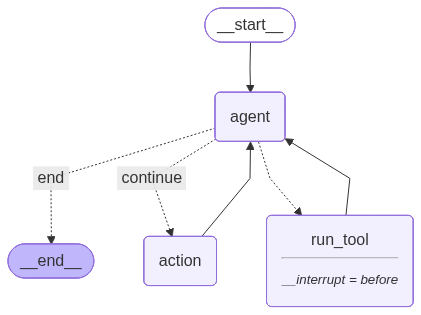

In [12]:
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
config={"configurable":{"thread_id":"10"}}

for chunk in graph.stream({"messages":"北京的天气怎么样？并把数据插入到数据库中"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

北京的天气怎么样？并把数据插入到数据库中
================================== Ai Message ==================================

我先查询北京的天气信息。
Tool Calls:
  get_weather (call_00_kaeOiqn6JdstverQK1Rq5950)
 Call ID: call_00_kaeOiqn6JdstverQK1Rq5950
  Args:
    location: Beijing
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 800, "main": "Clear", "description": "\u6674", "icon": "01d"}], "base": "stations", "main": {"temp": 33.27, "feels_like": 31.8, "temp_min": 33.27, "temp_max": 33.27, "pressure": 1003, "humidity": 26, "sea_level": 1003, "grnd_level": 998}, "visibility": 10000, "wind": {"speed": 3.79, "deg": 166, "gust": 3.97}, "clouds": {"all": 0}, "dt": 1782122600, "sys": {"country": "CN", "sunrise": 1782074768, "sunset": 1782128784}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}
=================

In [14]:
config={"configurable":{"thread_id":"100"}}

for chunk in graph.stream({"messages":"帮我同时查一下上海，杭州，天津的天气，比较哪个城市更适合现在出游。"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

帮我同时查一下上海，杭州，天津的天气，比较哪个城市更适合现在出游。
================================== Ai Message ==================================

好的，我先从数据库中查询这三个城市的天气信息。
Tool Calls:
  query_weather_from_db (call_00_Ftj9V2McTPV8iGmSOoWw1881)
 Call ID: call_00_Ftj9V2McTPV8iGmSOoWw1881
  Args:
    city_name: 上海
  query_weather_from_db (call_01_6R8lifk4kw6e3gP8p3sE7469)
 Call ID: call_01_6R8lifk4kw6e3gP8p3sE7469
  Args:
    city_name: 杭州
  query_weather_from_db (call_02_QAzyap9QK7uFW3zx4gtU9885)
 Call ID: call_02_QAzyap9QK7uFW3zx4gtU9885
  Args:
    city_name: 天津
2026-06-22 18:12:07,063 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-22 18:12:07,212 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like

In [20]:
config={"configurable":{"thread_id":"101"}}

for chunk in graph.stream({"messages":"帮我删除一下北京的天气数据"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

帮我删除一下北京的天气数据
================================== Ai Message ==================================

好的，我来帮您删除北京的天气数据。
Tool Calls:
  delete_weather_from_db (call_00_TMY988RToHNw9i2PuCEh8908)
 Call ID: call_00_TMY988RToHNw9i2PuCEh8908
  Args:
    city_name: 北京


In [ ]:
state=graph.get_state(config)
print(state.next)
print(state.tasks)
print(state.values)

In [22]:
for chunk in graph.stream(None,config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

看起来数据库中暂时没有找到名为"北京"的天气数据。让我尝试用英文名 "Beijing" 再查一下。
Tool Calls:
  delete_weather_from_db (call_00_tM60KBv6YAxlMkWZQkuK2076)
 Call ID: call_00_tM60KBv6YAxlMkWZQkuK2076
  Args:
    city_name: Beijing
2026-06-22 18:17:01,728 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-22 18:17:01,730 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-06-22 18:17:01,732 INFO sqlalchemy.engine.Engine [cached since 294.5s ago] {'city_name_1': 'Beijing', 'param_1': 1}
2026-06-22 18:17:01,737 INFO sqlalchemy.engine.Engine DELETE FROM

In [23]:
config={"configurable":{"thread_id":"102"}}

for chunk in graph.stream({"messages":"帮我同时查一下上海，杭州，天津的天气，比较哪个城市更适合现在出游。并且插入到数据库中"},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

帮我同时查一下上海，杭州，天津的天气，比较哪个城市更适合现在出游。并且插入到数据库中
================================== Ai Message ==================================

好的，我先查询这三个城市的天气信息。
Tool Calls:
  query_weather_from_db (call_00_XUFrhWSkhj50G9RIC3Lg9264)
 Call ID: call_00_XUFrhWSkhj50G9RIC3Lg9264
  Args:
    city_name: 上海
  query_weather_from_db (call_01_JP2uBdwE5NcdvTMaIhPt1907)
 Call ID: call_01_JP2uBdwE5NcdvTMaIhPt1907
  Args:
    city_name: 杭州
  query_weather_from_db (call_02_Uq3901zJqVyLwiMwANnb3887)
 Call ID: call_02_Uq3901zJqVyLwiMwANnb3887
  Args:
    city_name: 天津
2026-06-22 18:37:33,088 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-22 18:37:33,098 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-22 18:37:33,100 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.t